In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [35]:
# 1. Load dataset
df = pd.read_csv("Avocado.csv")

# Display first few rows
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [36]:
# 2. Create binary target and check correlations

df['HighPrice'] = (df['AveragePrice'] > df['AveragePrice'].median()).astype(int)

correlations = df.corr(numeric_only=True)['HighPrice'].abs().sort_values(ascending=False)
top_features = correlations[1:3].index.tolist()
print("Top 2 correlated features with target:", top_features)

Top 2 correlated features with target: ['AveragePrice', '4046']


In [37]:
# 3. Prepare features and target, split and scale

X = df[top_features].values
y = df['HighPrice'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Params: {'max_depth': None, 'min_samples_split': 2} | Accuracy: 1.0000


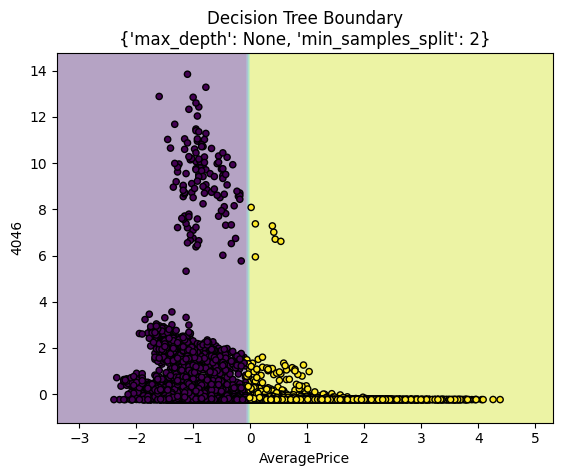

Params: {'max_depth': 3, 'min_samples_split': 2} | Accuracy: 1.0000


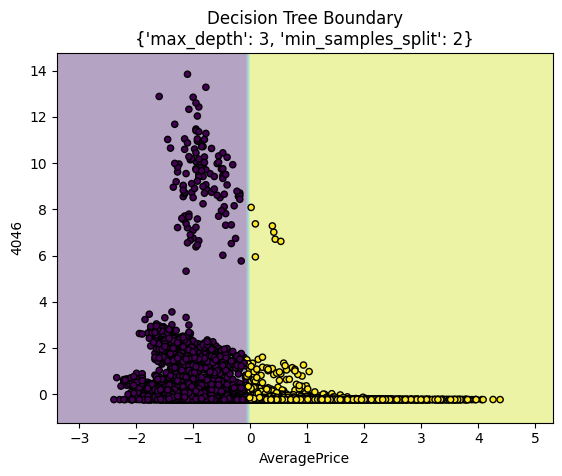

Params: {'max_depth': None, 'min_samples_split': 20} | Accuracy: 1.0000


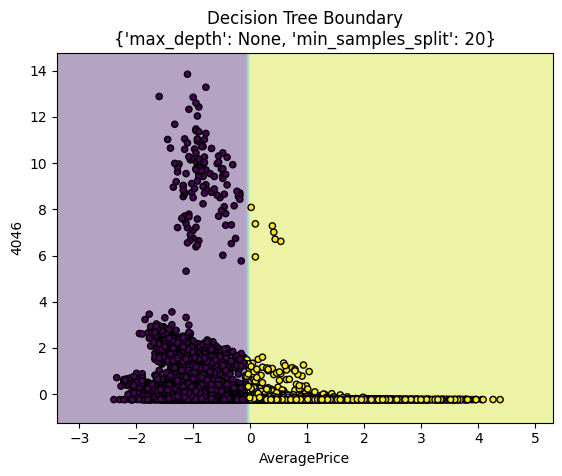

Params: {'max_depth': 3, 'min_samples_split': 3} | Accuracy: 1.0000


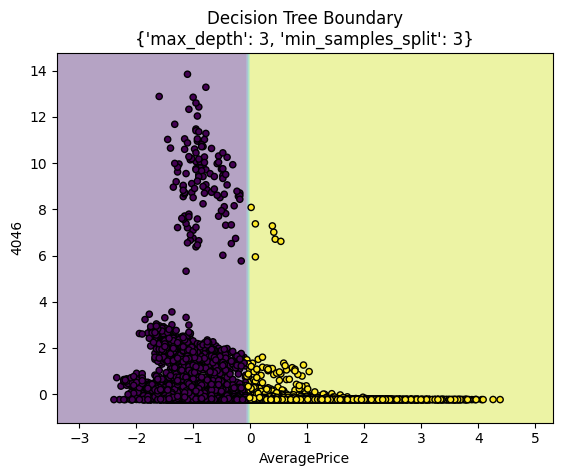

In [38]:
# 4. Decision Tree with different hyperparameters

params_list = [
    {"max_depth": None, "min_samples_split": 2},  
    {"max_depth": 3, "min_samples_split": 2},     
    {"max_depth": None, "min_samples_split": 20},  
    {"max_depth": 3, "min_samples_split": 3} 
]

for params in params_list:
    clf = DecisionTreeClassifier(random_state=42, **params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"Params: {params} | Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k')
    plt.xlabel(top_features[0])
    plt.ylabel(top_features[1])
    plt.title(f"Decision Tree Boundary\n{params}")
    plt.show()

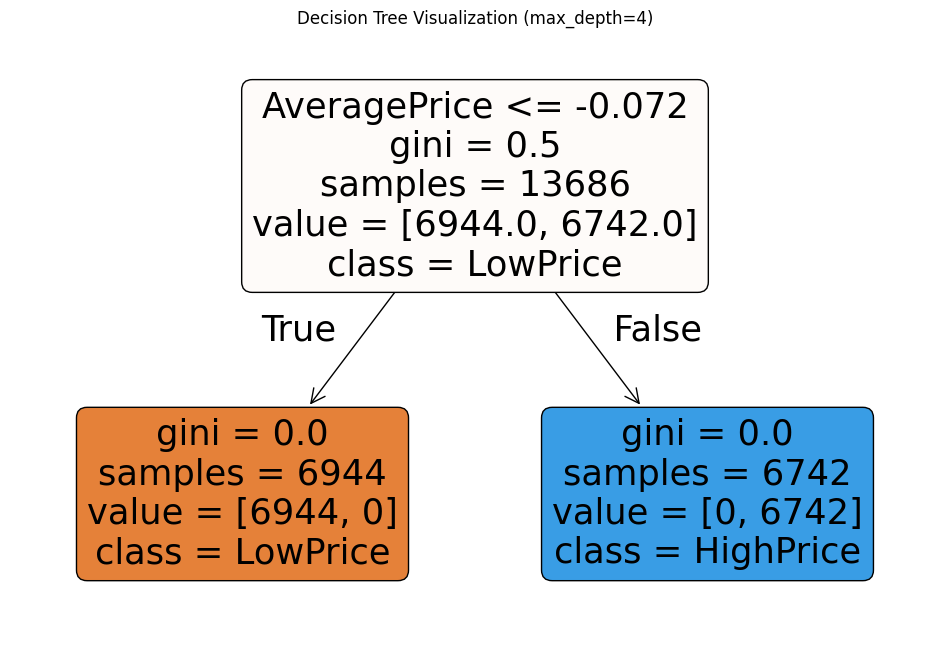

In [39]:
# 5. Display decision tree using sklearn (no external Graphviz needed)

from sklearn.tree import plot_tree

final_tree = DecisionTreeClassifier(random_state=42, max_depth=4)
final_tree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(final_tree,
          feature_names=top_features,
          class_names=["LowPrice", "HighPrice"],
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization (max_depth=4)")
plt.show()


In [40]:
# 6. Naive Bayes

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.888669734823581
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      2240
           1       0.82      0.99      0.90      2323

    accuracy                           0.89      4563
   macro avg       0.91      0.89      0.89      4563
weighted avg       0.91      0.89      0.89      4563



In [41]:
# 7. Random Forest with hyperparameter analysis

rf_params = [
    {"n_estimators": 10, "max_depth": None},
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 100, "max_depth": 3}
]

for params in rf_params:
    rf = RandomForestClassifier(random_state=42, **params)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    print(f"Random Forest {params} | Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest {'n_estimators': 10, 'max_depth': None} | Accuracy: 1.0000
Random Forest {'n_estimators': 100, 'max_depth': None} | Accuracy: 1.0000
Random Forest {'n_estimators': 100, 'max_depth': 3} | Accuracy: 1.0000
